# MNIST Digit Classification using Convolutional Neural Networks (CNN)

## Project Overview

This project implements a Convolutional Neural Network (CNN) from scratch using PyTorch to classify handwritten digits from the MNIST dataset.

The project covers the complete deep learning workflow:

1. Loading and preprocessing the dataset
2. Creating DataLoaders
3. Building a CNN model from scratch
4. Training the model
5. Evaluating the model
6. Predicting handwritten digits
7. Saving the trained model

## Dataset

1. Dataset: MNIST
2. Training Images: 60,000
3. Testing Images: 10,000
4. Image Size: 28 × 28
5. Number of Classes: 10

## Technologies Used

1. Python
2. PyTorch
3. Torchvision
4. NumPy
5. Matplotlib
6. Pillow

## Import libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image

from torchvision.datasets import MNIST
from torchvision import transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

## Load EMNIST Dataset

In [3]:
transform = transforms.ToTensor()

train_dataset = MNIST(
    root="./data",

    train=True,
    download=True,
    transform=transform
)

test_dataset = MNIST(
    root="./data",

    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 358kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.3MB/s]


## Create DataLoaders

In [4]:
batch_size=64
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

## Visualize Sample Images

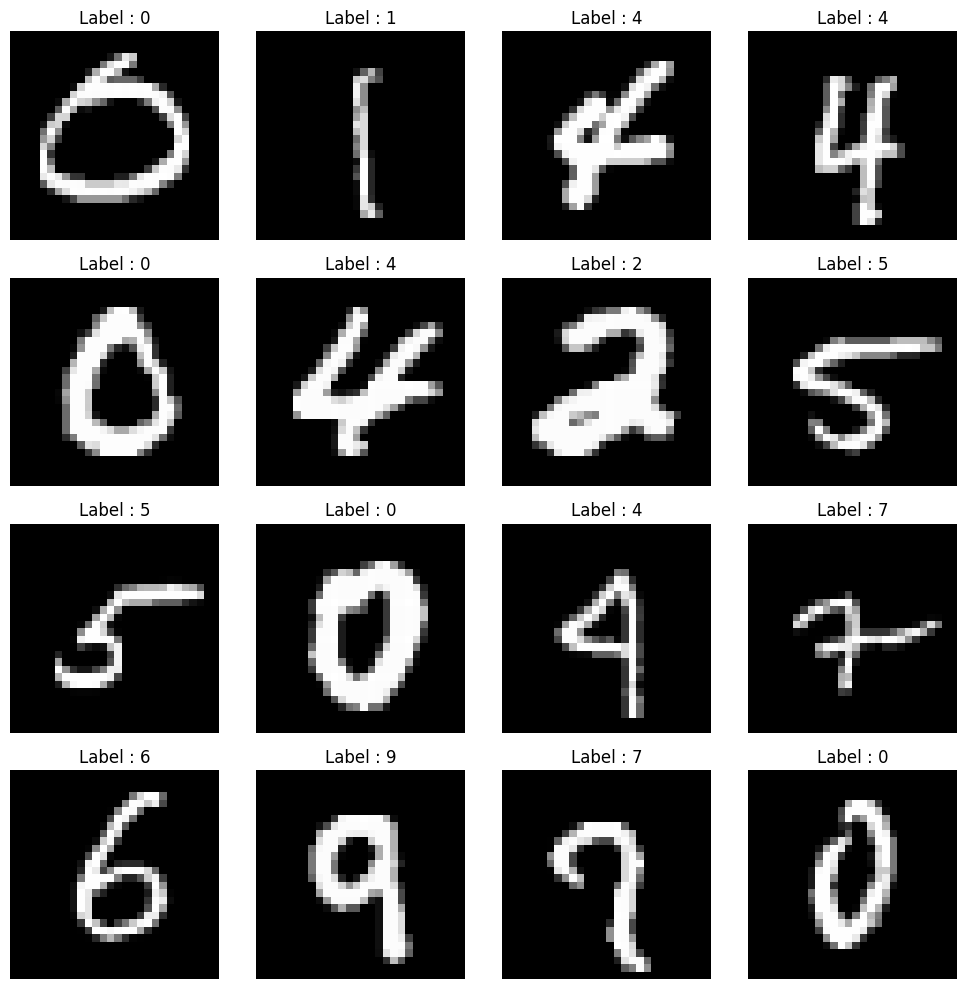

In [5]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,10))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(f"Label : {labels[i].item()}")

    plt.axis("off")

plt.tight_layout()

plt.show()

## Define Hyperparameters

In [6]:
batch_size = 64
learning_rate = 0.001
epochs = 5

## Build CNN Model

In [7]:
class CNN(nn.Module):

    def __init__(self):

        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(64 * 7 * 7, 128)

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.conv1(x)

        x = self.relu(x)

        x = self.pool(x)

        x = self.conv2(x)

        x = self.relu(x)

        x = self.pool(x)

        x = self.flatten(x)

        x = self.fc1(x)

        x = self.relu(x)

        x = self.fc2(x)

        return x

## Define Loss Function and Optimizer

In [8]:
model = CNN()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

## Train the CNN Model

In [24]:
for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

Epoch [1/5] - Loss: 0.0099
Epoch [2/5] - Loss: 0.0092
Epoch [3/5] - Loss: 0.0065
Epoch [4/5] - Loss: 0.0057
Epoch [5/5] - Loss: 0.0072


## Evaluate the Model

In [25]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(test_loader):

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()


accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.06%


## Predict a New Image

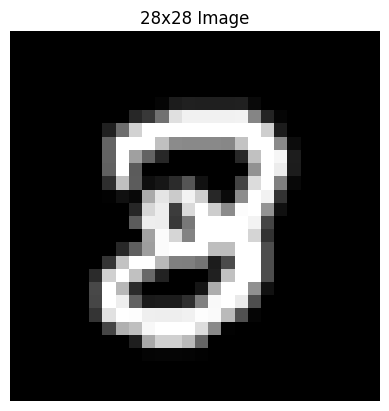

Predicted Digit: 8


In [27]:
image = Image.open("/content/digit_8.jpg").convert("L") #drop your photo

image = image.resize((28, 28))
image = transforms.ToTensor()(image)

# show the photo after preprocessing
plt.imshow(image.squeeze(), cmap="gray")
plt.title("28x28 Image")
plt.axis("off")
plt.show()

image = image.unsqueeze(0)

model.eval()

with torch.no_grad():
    output = model(image)
    prediction = torch.argmax(output, dim=1)

print("Predicted Digit:", prediction.item())

## Save the Trained Model

In [28]:
torch.save(model.state_dict(), "mnist_cnn.pth")

In [29]:
from google.colab import files

files.download("mnist_cnn.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>